In [ ]:
!cd ../../.. && maturin develop --uv

In [1]:
from orcapod import (
    Pod,
    PodJob,
    Uri,
    PathInfo,
    PathSet,
    Blob,
    BlobKind,
    Pipeline,
    PipelineJob,
    InputSpecUri,
    OutputSpecUri,
    Kernel,
)
from orcapod import LocalDockerOrchestrator
from pathlib import Path

In [3]:
namespace_lookup = {"default": "../../.tmp"}
root_dir = "test"

## Setup

In [4]:
input_dir = Path(namespace_lookup["default"]) / root_dir / "input"
input_dir.mkdir(parents=True, exist_ok=True)
for i in range(1, 16):
    (input_dir / f"{i}.txt").write_text(str(i))

In [5]:
add_pod = Pod(
    annotation=None,
    image="alpine:3.14",
    command=[
        "sh",
        "-c",
        """echo
            echo 'Adding two numbers'
            echo $(($(cat /tmp/input/left.txt)+$(cat /tmp/input/right.txt))) > /tmp/output/answer.txt
            echo Finished
        echo""".replace(
            "\n", " && "
        ),
    ],
    input_spec={
        "left": PathInfo(path="/tmp/input/left.txt", match_pattern=".*\.txt"),
        "right": PathInfo(path="/tmp/input/right.txt", match_pattern=".*\.txt"),
    },
    output_dir="/tmp/output",
    output_spec={
        "answer": PathInfo(path="/tmp/output/answer.txt", match_pattern=".*\.txt")
    },
    source_commit_url="https://place.holder",
    recommended_cpus=0.1,
    recommended_memory=10 << 20,
    required_gpu=None,
)

## PodJob Test

In [ ]:
add_pod_job = PodJob(
    annotation=None,
    pod=add_pod,
    input_packet={
        "left": PathSet.UNARY(
            blob=Blob(
                kind=BlobKind.FILE,
                location=Uri(namespace="default", path=f"{root_dir}/input/2.txt"),
                checksum="",
            )
        ),
        "right": PathSet.UNARY(
            blob=Blob(
                kind=BlobKind.FILE,
                location=Uri(namespace="default", path=f"{root_dir}/input/7.txt"),
                checksum="",
            )
        ),
    },
    output_dir=Uri(namespace="default", path=f"{root_dir}/output"),
    cpu_limit=0.1,
    memory_limit=10 << 20,
    env_vars=None,
    namespace_lookup=namespace_lookup,
)

In [ ]:
orch = LocalDockerOrchestrator()

In [ ]:
pod_run = orch.start_blocking(namespace_lookup=namespace_lookup, pod_job=add_pod_job)
pod_result = orch.get_result_blocking(pod_run=pod_run)

In [ ]:
orch.delete_blocking(pod_run=pod_run)

## PipelineJob Test

In [6]:
from IPython.display import SVG

In [7]:
map_left = {"answer": "left"}
map_right = {"answer": "right"}

In [8]:
pipeline = Pipeline(
    graph_dot="""
    digraph {
        add_a -> map_left_a -> cartesian_a -> add_e
        add_b -> map_right_a -> cartesian_a

        add_c -> map_left_b -> cartesian_b -> add_f
        add_d -> map_right_b -> cartesian_b

        add_e -> map_left_c -> cartesian_c -> add_g
        add_f -> map_right_c -> cartesian_c
    }
    """,
    metadata={
        **{
            f"add_{k}": Kernel.POD(ref=add_pod)
            for k in ["a", "b", "c", "d", "e", "f", "g"]
        },
        **{f"map_left_{k}": Kernel.MAP_OPERATOR(map=map_left) for k in ["a", "b", "c"]},
        **{
            f"map_right_{k}": Kernel.MAP_OPERATOR(map=map_right)
            for k in ["a", "b", "c"]
        },
        **{f"cartesian_{k}": Kernel.JOIN_OPERATOR() for k in ["a", "b", "c"]},
    },
    input_spec={
        **{
            f"left_add_{k}": [InputSpecUri(node_id=f"add_{k}", key="left")]
            for k in ["a", "b", "c", "d"]
        },
        **{
            f"right_add_{k}": [InputSpecUri(node_id=f"add_{k}", key="right")]
            for k in ["a", "b", "c", "d"]
        },
    },
    output_spec={"answer": OutputSpecUri(node_id="add_g", key="answer")},
)

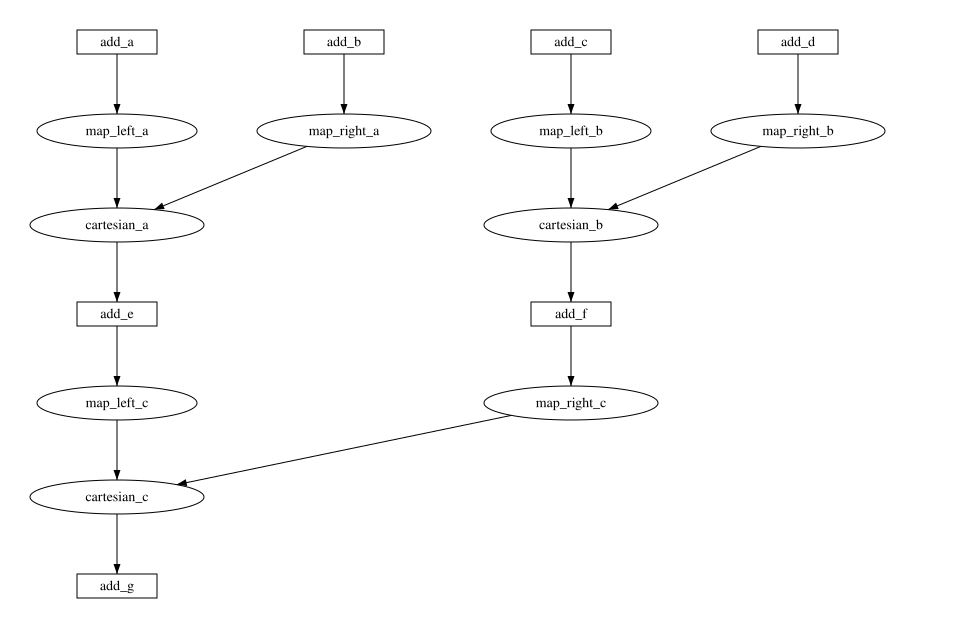

In [13]:
# pipeline.metadata()
# pipeline.metadata()["add_a"].ref.command()
# print(pipeline.make_dot())
SVG(data=pipeline.make_svg())

In [14]:
pipeline_job = PipelineJob(
    pipeline=pipeline,
    input_packet={
        "left_add_a": [
            PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{root_dir}/input/{i}.txt"),
                    checksum="",
                )
            )
            for i in range(1, 4)
        ],
        "right_add_a": [
            PathSet.UNARY(
                blob=Blob(
                    kind=BlobKind.FILE,
                    location=Uri(namespace="default", path=f"{root_dir}/input/{i}.txt"),
                    checksum="",
                )
            )
            for i in range(4, 6)
        ],
        **{
            k: [
                PathSet.UNARY(
                    blob=Blob(
                        kind=BlobKind.FILE,
                        location=Uri(
                            namespace="default", path=f"{root_dir}/input/{i+6}.txt"
                        ),
                        checksum="",
                    )
                )
            ]
            for i, k in enumerate(
                [
                    "left_add_b",
                    "right_add_b",
                    "left_add_c",
                    "right_add_c",
                    "left_add_d",
                    "right_add_d",
                ]
            )
        },
    },
    output_dir=Uri(namespace="default", path=f"{root_dir}/output"),
    namespace_lookup=namespace_lookup,
)

In [15]:
pipeline_job.input_packet()["left_add_a"][0].blob.checksum

'6b86b273ff34fce19d6b804eff5a3f5747ada4eaa22f1d49c01e52ddb7875b4b'

## Teardown

In [16]:
import shutil

In [ ]:
shutil.rmtree(Path(namespace_lookup["default"]) / root_dir / "output")

In [19]:
shutil.rmtree(Path(namespace_lookup["default"]) / root_dir)